In [9]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import geemap

from src.ndvi_ndwi import add_indices
from src.preprocess.aoi import load_city_aoi
from src.preprocess.gee_auth import initialize_ee
from src.preprocess.get_city_boundaries import Cities
from src.preprocess.load_and_preprocess_image import get_one_year_composite

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

initialize_ee()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
CITY = Cities.KARLSRUHE.value
aoi = load_city_aoi(CITY.name)
YEAR = 2025
image = add_indices(get_one_year_composite(aoi, YEAR))

index = "NDBI"  # choose from NDVI or NDWI

INDEX_PALETTES = {
    "NDVI": ["#d73027", "#ffffbf", "#1a9850"],  # red = low/no vegetation, green = dense
    "NDWI": ["#a6611a", "#f5f5f5", "#0571b0"],  # brown = dry, blue = water
    # green = vegetation/water, red = built-up
    "NDBI": ["#1a9850", "#ffffbf", "#a50026"],
}

INDEX_DIFF_PALETTES = {
    "NDVI": ["#a50026", "#ffffbf", "#1a9850"],  # red = vegetation loss, green = gain
    "NDWI": ["#8c510a", "#f5f5f5", "#01665e"],  # brown = water loss, teal = gain
    # green = less built-up, red = more built-up
    "NDBI": ["#1a9850", "#f7f7f7", "#a50026"],
}

LST_DIFF_PALETTE = ["#2166ac", "#f7f7f7", "#b2182b"]  # blue = cooling, red = warming

LST_SOURCE_BY_CITY = {
    # Landsat 8 splits Karlsruhe across 2 WRS-2 paths, causing a seam artifact
    "Karlsruhe": "modis",
}
lst_source = LST_SOURCE_BY_CITY.get(CITY.name, "landsat")

In [ ]:
import ee
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np


def show_index_map(aoi: ee.Geometry, image: ee.Image, index: str) -> geemap.Map:
    index_vis = {"min": -1, "max": 1, "palette": INDEX_PALETTES[index]}

    Map = geemap.Map()
    Map.centerObject(aoi, zoom=11)
    Map.addLayer(image.select(index), index_vis, index)
    Map.add_colorbar(index_vis, label=index)
    return Map


# show_index_map(aoi, image, "NDVI")


def show_static_index_map(
    aoi: ee.Geometry, image: ee.Image, index: str, buffer_meters: int = 1000
) -> None:
    buffered_aoi = aoi.buffer(buffer_meters)
    index_array = geemap.ee_to_numpy(
        image, region=buffered_aoi, bands=[index], scale=30
    )[:, :, 0]
    # ee.data.computePixels fills masked/no-data pixels with 0 (not NaN), so treat
    # exact zeros as no-data to render them white via cmap.set_bad instead of the
    # colormap's midpoint color.
    index_array = np.where(index_array == 0, np.nan, index_array)

    plt.figure(figsize=(8, 8))
    cmap = mcolors.LinearSegmentedColormap.from_list(index, INDEX_PALETTES[index])
    cmap.set_bad(color="white")
    im = plt.imshow(index_array, cmap=cmap, vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.02, pad=0.02, shrink=0.35, aspect=30)
    plt.title(f"{index}: {CITY.name} {YEAR}")
    plt.axis("off")
    plt.show()


# show_static_index_map(aoi, image, index)

In [4]:
import ee

from src.preprocess.load_and_preprocess_image import (
    END_YEAR,
    START_YEAR,
    get_one_year_composite,
)


def compute_index_trend(
    aoi: ee.Geometry, start_year: int, end_year: int, index: str
) -> tuple[list[int], list[float]]:
    years = list(range(start_year, end_year + 1))
    mean_values = []
    for year in years:
        image = add_indices(
            get_one_year_composite(aoi, year, start_month=6, end_month=8)
        )
        mean_value = (
            image.select(index)
            .reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=aoi,
                scale=30,
                bestEffort=True,
                maxPixels=1e9,
            )
            .get(index)
            .getInfo()
        )
        mean_values.append(mean_value)
    return years, mean_values

In [5]:
def plot_index_trend(
    years: list[int], mean_values: list[float], city_name: str, index: str
) -> None:
    plt.plot(years, mean_values, marker="o")
    plt.xlabel("Year")
    plt.ylabel(f"Mean {index}")
    plt.title(f"Mean {index} trend: {city_name} (June-August)")
    plt.grid(True)
    plt.show()


years, mean_values = compute_index_trend(aoi, START_YEAR, END_YEAR, index=index)
# plot_index_trend(years, mean_values, CITY.name, index=index)

In [ ]:
def compute_index_diff(
    aoi: ee.Geometry, start_year: int, end_year: int, index: str
) -> ee.Image:
    start_image = add_indices(
        get_one_year_composite(aoi, start_year, start_month=6, end_month=8)
    )
    end_image = add_indices(
        get_one_year_composite(aoi, end_year, start_month=6, end_month=8)
    )
    return (
        end_image.select(index)
        .subtract(start_image.select(index))
        .rename(f"{index}_diff")
    )


def show_index_diff_map(
    aoi: ee.Geometry, start_year: int, end_year: int, index: str
) -> geemap.Map:
    diff_image = compute_index_diff(aoi, start_year, end_year, index)
    diff_vis = {"min": -0.3, "max": 0.3, "palette": INDEX_DIFF_PALETTES[index]}

    Map = geemap.Map()
    Map.centerObject(aoi, zoom=11)
    Map.addLayer(diff_image, diff_vis, f"{index} change {start_year}-{end_year}")
    Map.add_colorbar(diff_vis, label=f"{index} change ({start_year}-{end_year})")
    return Map


# show_index_diff_map(aoi, START_YEAR, END_YEAR, index)


def show_index_diff_static(
    aoi: ee.Geometry,
    start_year: int,
    end_year: int,
    index: str,
    buffer_meters: int = 1000,
) -> None:
    buffered_aoi = aoi.buffer(buffer_meters)
    diff_image = compute_index_diff(aoi, start_year, end_year, index)
    diff_array = geemap.ee_to_numpy(
        diff_image, region=buffered_aoi, bands=[f"{index}_diff"], scale=30
    )[:, :, 0]
    # ee.data.computePixels fills masked/no-data pixels with 0 (not NaN), so treat
    # exact zeros as no-data to render them white via cmap.set_bad instead of the
    # colormap's midpoint color.
    diff_array = np.where(diff_array == 0, np.nan, diff_array)

    plt.figure(figsize=(8, 8))
    cmap = mcolors.LinearSegmentedColormap.from_list(
        f"{index}_diff", INDEX_DIFF_PALETTES[index]
    )
    cmap.set_bad(color="white")
    im = plt.imshow(diff_array, cmap=cmap, vmin=-0.3, vmax=0.3)
    plt.colorbar(im, fraction=0.02, pad=0.02, shrink=0.35, aspect=30)
    plt.title(f"{index} change: {CITY.name} ({start_year} to {end_year})")
    plt.axis("off")
    plt.show()


# show_index_diff_static(aoi, START_YEAR, END_YEAR, index)

In [ ]:
import ee

from src.preprocess.load_and_preprocess_image import (
    END_YEAR,
    START_YEAR,
    get_one_year_lst_composite,
)


def compute_lst_trend(
    aoi: ee.Geometry, start_year: int, end_year: int, source: str = "landsat"
) -> tuple[list[int], list[float]]:
    years = list(range(start_year, end_year + 1))
    mean_values = []
    for year in years:
        image = get_one_year_lst_composite(
            aoi, year, start_month=6, end_month=8, source=source
        )
        mean_value = (
            image.select("LST")
            .reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=aoi,
                scale=30,
                bestEffort=True,
                maxPixels=1e9,
            )
            .get("LST")
            .getInfo()
        )
        mean_values.append(mean_value)
    return years, mean_values


def plot_lst_trend(years: list[int], mean_values: list[float], city_name: str) -> None:
    plt.plot(years, mean_values, marker="o")
    plt.xlabel("Year")
    plt.ylabel("Mean LST (°C)")
    plt.title(f"Mean LST trend: {city_name} (June-August)")
    plt.grid(True)
    plt.show()


# years, mean_values = compute_lst_trend(aoi, START_YEAR, END_YEAR, source=lst_source)
# plot_lst_trend(years, mean_values, CITY.name)

In [ ]:
def compute_lst_diff(
    aoi: ee.Geometry, start_year: int, end_year: int, source: str = "landsat"
) -> ee.Image:
    start_image = get_one_year_lst_composite(
        aoi, start_year, start_month=6, end_month=8, source=source
    )
    end_image = get_one_year_lst_composite(
        aoi, end_year, start_month=6, end_month=8, source=source
    )
    return (
        end_image.select("LST").subtract(start_image.select("LST")).rename("LST_diff")
    )


def show_lst_diff_static(
    aoi: ee.Geometry,
    start_year: int,
    end_year: int,
    source: str = "landsat",
    buffer_meters: int = 1000,
) -> None:
    buffered_aoi = aoi.buffer(buffer_meters)
    diff_image = compute_lst_diff(aoi, start_year, end_year, source=source)
    diff_array = geemap.ee_to_numpy(
        diff_image, region=buffered_aoi, bands=["LST_diff"], scale=30
    )[:, :, 0]
    diff_array = np.where(diff_array == 0, np.nan, diff_array)

    plt.figure(figsize=(8, 8))
    cmap = mcolors.LinearSegmentedColormap.from_list("LST_diff", LST_DIFF_PALETTE)
    cmap.set_bad(color="white")
    im = plt.imshow(diff_array, cmap=cmap, vmin=-5, vmax=5)
    plt.colorbar(
        im, label="LST change (°C)", fraction=0.02, pad=0.02, shrink=0.35, aspect=30
    )
    plt.title(f"LST change: {CITY.name} ({start_year} to {end_year}) [{source}]")
    plt.axis("off")
    plt.show()


# show_lst_diff_static(aoi, START_YEAR, END_YEAR, source=lst_source)

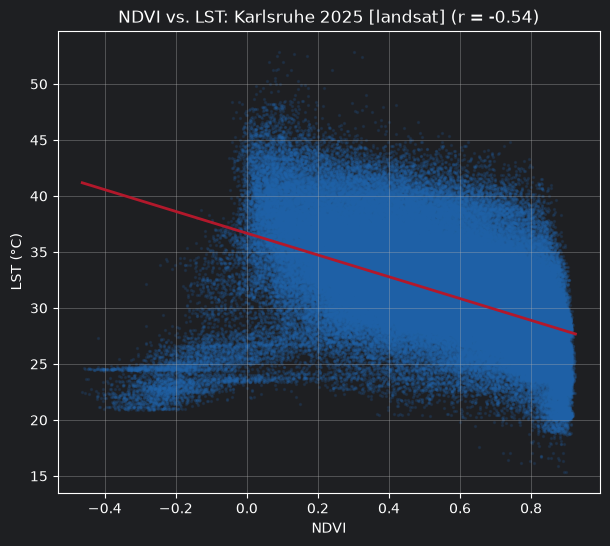

In [14]:
from src.urban_heat_island import compute_lst_index_correlation


def plot_lst_index_scatter(data: dict, city_name: str, source: str = "landsat") -> None:
    x, y = data["index_values"], data["lst_values"]
    slope, intercept = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)

    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, s=2, alpha=0.15, color="#2166ac")
    plt.plot(x_line, slope * x_line + intercept, color="#b2182b", linewidth=2)
    plt.xlabel(data["index"])
    plt.ylabel("LST (°C)")
    plt.title(
        f"{data['index']} vs. LST: {city_name} {data['year']} "
        f"[{source}] (r = {data['correlation']:.2f})"
    )
    plt.grid(True)
    plt.show()


lst_source = "landsat"
corr_data = compute_lst_index_correlation(aoi, 2025, "NDVI", source=lst_source)
plot_lst_index_scatter(corr_data, CITY.name, source=lst_source)